In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
import pandas as pd
import os
from tp7.tp7 import Tape7
import scipy.integrate as integrate
from srfs.srfs import SRFS

In [2]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

In [3]:
a00_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA85")

In [4]:
def plot_radiance(rads, title, runnum):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]
    # print('')
    # print(describer_df)
    # print(np.shape(rads))
    print(np.shape(rads), print(runnum))
    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    # ax.plot(rads[:,0,runnum], rads[:,1, runnum], 'r-', label='SW Radiance')
    ax.plot(rads[runnum, 0, :], rads[runnum, 1, :], 'r-', label='SW Radiance')
    #ax.plot(rads[:,0,runnum], rads[:,2, runnum], 'b-', label='LW Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    plt.xlim(0,5)

In [5]:
a00_data = [Tape7(file) for file in a00_files]

In [6]:
a00_data

In [7]:
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

In [8]:
a00

{'Snow': <tp7.tp7.Tape7 at 0x13943fc40>,
 'Land': <tp7.tp7.Tape7 at 0x13943fa00>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x13943fdf0>,
 'Cloudy Ocean': <tp7.tp7.Tape7 at 0x17bb17d60>,
 'Deep Convective Cloud': <tp7.tp7.Tape7 at 0x10381f7f0>}

In [5]:
snow = a00_files[0]
land = a00_files[1]
clear = a00_files[2]
cloudy = a00_files[3]
deep = a00_files[4]

# land = Tape7(land)
snow = Tape7(snow)
# clear = Tape7(clear)
# cloudy = Tape7(cloudy)
# deep = Tape7(deep)


In [ ]:
# land = a00["Land"]
snow.title, land.title, clear.title, cloudy.title, deep.title

In [7]:
land.build_scene_description()

,Scene,SZA,VZA,RAZ,Cld Type,Run #
0,Land,0.0,0.000,0.0,0,0
1,Land,0.0,0.000,0.0,1,1
2,Land,0.0,0.000,0.0,1,2
3,Land,0.0,0.000,0.0,1,3
4,Land,0.0,0.000,0.0,1,4
...,...,...,...,...,...,...
625,Land,0.0,79.914,172.5,0,625
626,Land,0.0,79.914,172.5,1,626
627,Land,0.0,79.914,172.5,1,627
628,Land,0.0,79.914,172.5,1,628


In [6]:
snow.build_scene_description()

,Scene,SZA,VZA,RAZ,Cld Type,Run #
0,Snow,0.000,0.000,0.0,0,0
1,Snow,0.000,0.000,0.0,1,1
2,Snow,0.000,0.000,0.0,1,2
3,Snow,0.000,0.000,0.0,1,3
4,Snow,0.000,0.000,0.0,1,4
...,...,...,...,...,...,...
310,Snow,9.156,89.947,172.5,0,310
311,Snow,9.156,89.947,172.5,1,311
312,Snow,9.156,89.947,172.5,1,312
313,Snow,9.156,89.947,172.5,1,313


In [7]:
snow.integrate_unfiltered_radiances()

ValueError: Length of values (0) does not match length of index (315)

In [9]:
clear.build_scene_description()

,Scene,SZA,VZA,RAZ,Cloud,Run #
0,Clear Ocean,0.000,0.000,0.0,0,0
1,Clear Ocean,0.000,0.000,0.0,0,1
2,Clear Ocean,0.000,0.000,0.0,0,2
3,Clear Ocean,0.000,0.000,0.0,0,3
4,Clear Ocean,0.000,0.000,0.0,0,4
...,...,...,...,...,...,...
142,Clear Ocean,9.047,89.947,172.5,0,142
143,Clear Ocean,9.047,89.947,172.5,0,143
144,Clear Ocean,9.047,89.947,172.5,0,144
145,Clear Ocean,9.047,89.947,172.5,0,145


In [12]:
land.describer_df

,Scene,SZA,VZA,RAZ,Cld Type,Run #
0,Land,0.0,0.000,0.0,No cloud,0
1,Land,0.0,0.000,0.0,ICLD 18: cirrus cloud,1
2,Land,0.0,0.000,0.0,ICLD 18: cirrus cloud,2
3,Land,0.0,0.000,0.0,ICLD 3: stratus cloud,3
4,Land,0.0,0.000,0.0,ICLD 1: cumulus cloud,4
...,...,...,...,...,...,...
625,Land,0.0,79.914,172.5,No cloud,625
626,Land,0.0,79.914,172.5,ICLD 18: cirrus cloud,626
627,Land,0.0,79.914,172.5,ICLD 18: cirrus cloud,627
628,Land,0.0,79.914,172.5,ICLD 3: stratus cloud,628


In [1]:
mapping = {
    'No cloud': 0,
    'ICLD 18: cirrus cloud': 1,
    'ICLD 3: stratus cloud': 1,
    'ICLD 1: cumulus cloud': 1,
}

clean_clouds_land = land.describer_df["Cld Type"].map(mapping)
clean_clouds_land

NameError: name 'land' is not defined

In [20]:
unfilt_short_land, unfilt_long_land = land.integrate_unfiltered_radiances()
unfiltered_land_y[0].shape

(630,)

(630, 3, 4000)

In [13]:
for run in land.rads:
    print(np.shape(run[0]))

(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)


0
(630, 3, 4000) None


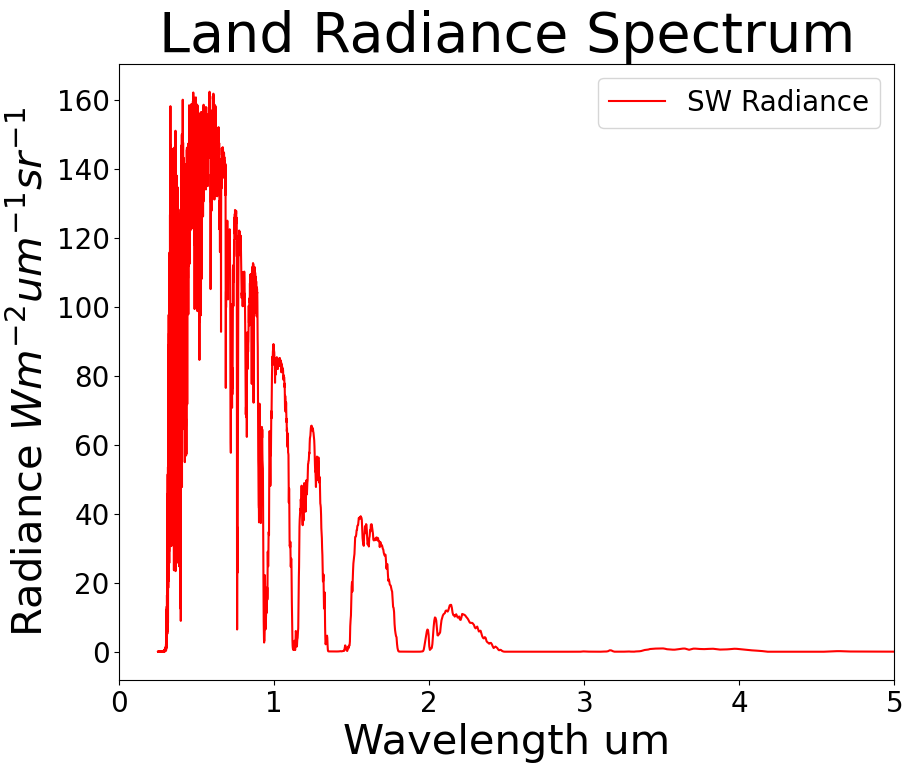

In [13]:
plot_radiance(land.rads, land.title, 0)

In [23]:
wavelength_run_629 = land.rads[629, 0, :]

In [16]:
for i in wavelength_run_629:
    print(i)

1000.0
500.0
333.3333333333333
250.0
200.0
166.66666666666666
142.85714285714286
125.0
111.11111111111111
100.0
90.9090909090909
83.33333333333333
76.92307692307693
71.42857142857143
66.66666666666667
62.5
58.8235294117647
55.55555555555556
52.63157894736842
50.0
47.61904761904762
45.45454545454545
43.47826086956522
41.666666666666664
40.0
38.46153846153847
37.03703703703704
35.714285714285715
34.48275862068965
33.333333333333336
32.25806451612903
31.25
30.303030303030305
29.41176470588235
28.571428571428573
27.77777777777778
27.027027027027028
26.31578947368421
25.641025641025642
25.0
24.390243902439025
23.80952380952381
23.25581395348837
22.727272727272727
22.22222222222222
21.73913043478261
21.27659574468085
20.833333333333332
20.408163265306126
20.0
19.607843137254903
19.230769230769234
18.867924528301888
18.51851851851852
18.181818181818183
17.857142857142858
17.54385964912281
17.241379310344826
16.949152542372882
16.666666666666668
16.39344262295082
16.129032258064516
15.87301587

In [24]:

sw_run_629 =  land.rads[629, 1, :]
integral_value = -integrate.simpson(x=wavelength_run_629, y=sw_run_629)
integral_value

np.float64(235.48130214412734)

In [18]:
sw_uf_int_629 = land.integrate_unfiltered_radiances()

In [19]:
sw_uf_int_629[0]

array([101.9436102 , 103.19933862, 155.59730079, 250.69099325,
       339.79956592,  77.53575395,  85.72634889, 146.43304861,
       248.51280003, 339.79800386,  97.84888211, 103.32909697,
       156.43761429, 256.43798255, 344.71408395,  42.41220482,
        64.56860314, 136.73174305, 257.26077226, 352.79874677,
        51.85132317,  69.99518485, 139.15352323, 257.84124239,
       352.79874677,  78.17788306,  89.58158464, 148.85073542,
       269.04936292, 352.41007459, 100.80109785, 101.26763981,
       155.36384984, 249.59542538, 336.01228029,  76.87608837,
        84.73220451, 146.92197396, 247.59333727, 336.01100823,
        96.22965001, 101.69560571, 156.0673556 , 254.71616476,
       340.67509601,  42.11152174,  65.15983637, 137.96436161,
       256.02532867, 348.70660312,  51.34506897,  70.26941492,
       140.19122275, 256.55787899, 348.70662979,  77.20906887,
        88.72255803, 149.05795876, 267.97932829, 348.77411482,
       100.81605982, 101.2740363 , 155.36979861, 249.61

In [15]:
type(wavelength_run_629)

numpy.ndarray

In [16]:
np.all(np.diff(wavelength_run_629) > 0)

np.False_

In [17]:
# np.savetxt("./data/wv629.txt", wavelength_run_629)

In [18]:
integral_value

np.float64(235.48130214412734)

In [19]:
land_wvln = land.rads[:, 0, :]
land_sw = land.rads[:, 1, :]
land_lw = land.rads[:, 2, :]

print(np.shape(land_sw), np.shape(land_lw))

land00_sw_unfiltered_radiances = [integrate.simpson(y=land_wvln[:, i] , x=land_sw[:, i]) for i in range(land_sw.shape[1] - 1)]
land00_lw_unfiltered_radiances = [integrate.simpson(y=land_wvln[:, i] , x=land_lw[:, i]) for i in range(land_lw.shape[1] - 1)]

(4000, 630) (4000, 630)


array([ True,  True,  True, ...,  True,  True,  True])

In [20]:
land00_sw_unfiltered_radiances

[np.float64(102.31928527530097),
 np.float64(103.81387839774891),
 np.float64(159.1481486000823),
 np.float64(316.03906076224393),
 np.float64(346.6548942330293),
 np.float64(78.28261684756308),
 np.float64(86.33920502378857),
 np.float64(146.7643543013044),
 np.float64(297.68783674244526),
 np.float64(345.91817420965356),
 np.float64(97.883585719143),
 np.float64(103.58348479851017),
 np.float64(156.50672638701624),
 np.float64(264.8629911171979),
 np.float64(352.5154550053464),
 np.float64(42.84141527262163),
 np.float64(65.0791584978992),
 np.float64(137.18455406926483),
 np.float64(273.16643683766875),
 np.float64(359.4977435186633),
 np.float64(52.43058603583969),
 np.float64(71.21537740172506),
 np.float64(138.23317718956307),
 np.float64(273.7369499131099),
 np.float64(359.4977435186633),
 np.float64(78.60543380278251),
 np.float64(84.24453612979298),
 np.float64(148.49214217023027),
 np.float64(288.5505723839168),
 np.float64(363.28995198524325),
 np.float64(101.96802259492922)

In [21]:
land00_lw_unfiltered_radiances

[np.float64(248861.02903757937),
 np.float64(70.38431111042331),
 np.float64(60.635739955067386),
 np.float64(94.06799233688763),
 np.float64(86.594535292493),
 np.float64(31624993.316934895),
 np.float64(1465.981816519733),
 np.float64(60.62204717444198),
 np.float64(93.97803314923794),
 np.float64(86.594535292493),
 np.float64(253991604.7878418),
 np.float64(70.09367038852429),
 np.float64(59.34556293633371),
 np.float64(84.62798876963733),
 np.float64(71.09108363568365),
 np.float64(3612621.799441942),
 np.float64(57.998856299889106),
 np.float64(50.159436776232326),
 np.float64(79.87772496780218),
 np.float64(66.02135584332537),
 np.float64(3571655.830453963),
 np.float64(57.75323218572574),
 np.float64(50.140735203682624),
 np.float64(80.44183994114087),
 np.float64(66.0213562406714),
 np.float64(-8249897.205815155),
 np.float64(54.11060959705119),
 np.float64(46.973732396680965),
 np.float64(72.91487883559039),
 np.float64(68.6288226932692),
 np.float64(100381758.93555467),
 np.f

In [22]:
land00_describer = land.describer_df

In [23]:
land00_describer

,Scene,SZA,VZA,RAZ,Atm model,Sfc Temp,Albedo model,Season,Aerosol Type,Met Range,Wind spd (ms-1),Cld Type,Cld Alt (km),Cld Thick (km),Cld Ext Coef (km-1),Run #
0,Land,0.0,0.000,0.0,Tropical,310.0,-2.0,Spring/Summer,Desert,37.82713,5.0,No cloud,0.00,0.00,0.0,0
1,Land,0.0,0.000,0.0,Tropical,310.0,-2.0,Spring/Summer,Desert,37.82713,5.0,ICLD 18: cirrus cloud,7.00,1.00,4.0,1
2,Land,0.0,0.000,0.0,Tropical,310.0,-2.0,Spring/Summer,Desert,37.82713,5.0,ICLD 18: cirrus cloud,7.00,2.00,6.0,2
3,Land,0.0,0.000,0.0,Tropical,310.0,-2.0,Spring/Summer,Desert,37.82713,5.0,ICLD 3: stratus cloud,0.50,0.20,28.0,3
4,Land,0.0,0.000,0.0,Tropical,310.0,-2.0,Spring/Summer,Desert,37.82713,5.0,ICLD 1: cumulus cloud,0.66,2.34,92.6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,Land,0.0,79.914,172.5,Midlatitude Winter,275.0,-7.0,Fall/Winter,Rural,25.00000,0.0,No cloud,0.00,0.00,0.0,625
626,Land,0.0,79.914,172.5,Midlatitude Winter,275.0,-7.0,Fall/Winter,Rural,25.00000,0.0,ICLD 18: cirrus cloud,7.00,1.00,4.0,626
627,Land,0.0,79.914,172.5,Midlatitude Winter,275.0,-7.0,Fall/Winter,Rural,25.00000,0.0,ICLD 18: cirrus cloud,7.00,2.00,6.0,627
628,Land,0.0,79.914,172.5,Midlatitude Winter,275.0,-7.0,Fall/Winter,Rural,25.00000,0.0,ICLD 3: stratus cloud,0.50,0.20,28.0,628


In [44]:
srfs = pd.read_csv("../data/libera_srfs_20241017.csv")

In [25]:
srfs

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865
4,0.307060,0.0,0.0,0.00000,0.00000,0.01218,0.01218,0.00818,0.00818
...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000


In [35]:
hold = [wavelength_run_629, sw_run_629]
hold

[array([1.00000000e+03, 5.00000000e+02, 3.33333333e+02, ...,
        2.50125063e-01, 2.50062516e-01, 2.50000000e-01]),
 array([5.16780000e-24, 7.99800000e-22, 1.39023000e-20, ...,
        3.29590162e-02, 3.23294292e-02, 3.43072000e-02])]

In [26]:
for index, row in srfs.iterrows():
    next_index = index + 1
    if next_index not in srfs.index:
        continue
    else:
        srfs.loc[index, 'End_wv_range'] = srfs.loc[next_index, 'wavelength [um]']

In [36]:
srfs

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf,End_wv_range
0,0.000000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.300000
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.301750
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006,0.303509
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933,0.305279
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865,0.307060
...,...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000,98.270641
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000,98.843745
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000,99.420192
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000,100.000000


In [28]:
sw_run_629

array([5.16780000e-24, 7.99800000e-22, 1.39023000e-20, ...,
       3.29590162e-02, 3.23294292e-02, 3.43072000e-02])

In [29]:
# for i in wavelength_run_629:
#     print(i)
new_row = srfs.iloc[0].copy()
new_row.loc['End_wv_range'] = new_row['wavelength [um]']
new_row.loc['wavelength [um]'] = 0.0
data, cols = new_row.values, new_row.index
print(cols)
tdf = pd.DataFrame([data], columns=cols)
# new_row = new_row.reset_index()
# tdf = pd.DataFrame(new_row.values, columns=new_row.index)
srfs = pd.concat([tdf, srfs])
srfs

Index(['wavelength [um]', ' ssw srf', ' conv ssw srf', ' lw srf',
       ' conv lw srf', ' total srf', ' conv total srf', ' sw srf',
       ' conv sw srf', 'End_wv_range'],
      dtype='object')


,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf,End_wv_range
0,0.000000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.300000
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.301750
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006,0.303509
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933,0.305279
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865,0.307060
...,...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000,98.270641
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000,98.843745
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000,99.420192
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000,100.000000


In [26]:
# srfs.to_csv("./data/srfs.csv")

In [27]:
np.shape(wavelength_run_629)

(4000,)

In [28]:
for i in range(len(wavelength_run_629)):
    print(wavelength_run_629[i])

1000.0
500.0
333.3333333333333
250.0
200.0
166.66666666666666
142.85714285714286
125.0
111.11111111111111
100.0
90.9090909090909
83.33333333333333
76.92307692307693
71.42857142857143
66.66666666666667
62.5
58.8235294117647
55.55555555555556
52.63157894736842
50.0
47.61904761904762
45.45454545454545
43.47826086956522
41.666666666666664
40.0
38.46153846153847
37.03703703703704
35.714285714285715
34.48275862068965
33.333333333333336
32.25806451612903
31.25
30.303030303030305
29.41176470588235
28.571428571428573
27.77777777777778
27.027027027027028
26.31578947368421
25.641025641025642
25.0
24.390243902439025
23.80952380952381
23.25581395348837
22.727272727272727
22.22222222222222
21.73913043478261
21.27659574468085
20.833333333333332
20.408163265306126
20.0
19.607843137254903
19.230769230769234
18.867924528301888
18.51851851851852
18.181818181818183
17.857142857142858
17.54385964912281
17.241379310344826
16.949152542372882
16.666666666666668
16.39344262295082
16.129032258064516
15.87301587

In [29]:
min(wavelength_run_629)

np.float64(0.25)

In [30]:
.3 in wavelength_run_629

False

In [31]:
srfs.columns

Index(['wavelength [um]', ' ssw srf', ' conv ssw srf', ' lw srf',
       ' conv lw srf', ' total srf', ' conv total srf', ' sw srf',
       ' conv sw srf', 'End_wv_range'],
      dtype='object')

In [42]:
srfs

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf,End_wv_range
0,0.000000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.300000
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.301750
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006,0.303509
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933,0.305279
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865,0.307060
...,...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000,98.270641
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000,98.843745
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000,99.420192
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000,100.000000


In [37]:
srfs.loc[999, 'End_wv_range'] = 110

In [38]:
srfs

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf,End_wv_range
0,0.000000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.300000
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.301750
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006,0.303509
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933,0.305279
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865,0.307060
...,...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000,98.270641
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000,98.843745
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000,99.420192
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000,100.000000


In [47]:
wvs629 = pd.read_csv("./data/wv629.txt", header=None).squeeze()

In [50]:
np.shape(wvs629)

(4000,)

In [36]:
bins = pd.IntervalIndex.from_arrays(srfs['wavelength [um]'], srfs['End_wv_range'], closed='left')

binned_data = pd.cut(wavelength_run_629, bins)

In [38]:
for i in binned_data:
    print(i)

nan
nan
nan
nan
nan
nan
nan
nan
nan
[100.0, 110.0)
[90.58747, 91.115767)
[83.020829, 83.504998)
[76.529946, 76.976261)
[71.371785, 71.788018)
[66.561287, 66.949465)
[62.437034, 62.80116)
[58.568327, 58.909891)
[55.259732, 55.582001)
[52.442108, 52.747945)
[49.768151, 50.058393)
[47.505979, 47.783029)
[45.346632, 45.611089)
[43.285437, 43.537873)
[41.558893, 41.80126)
[39.901217, 40.133917)
[38.309662, 38.53308)
[36.996095, 37.211853)
[35.520417, 35.727569)
[34.302489, 34.502538)
[33.319511, 33.513827)
[32.177047, 32.364701)
[31.073757, 31.254976)
[30.183302, 30.359328)
[29.318363, 29.489345)
[28.478211, 28.644293)
[27.662134, 27.823457)
[27.026143, 27.183756)
[26.251677, 26.404774)
[25.499404, 25.648114)
[24.913137, 25.058427)
[24.340348, 24.482299)
[23.78073, 23.919416)
[23.233977, 23.369475)
[22.699795, 22.832178)
[22.177895, 22.307234)
[21.667994, 21.79436)
[21.169816, 21.293277)
[20.803714, 20.925039)
[20.325408, 20.443943)
[19.973908, 20.090394)
[19.51468, 19.628488)
[19.177201, 1

In [39]:
bin_df = pd.DataFrame({
    "Wavelength" : wavelength_run_629,
    "Range" : binned_data
})
bin_df

,Wavelength,Range
0,1000.000000,NaN
1,500.000000,NaN
2,333.333333,NaN
3,250.000000,NaN
4,200.000000,NaN
...,...,...
3995,0.250250,"[0.0, 0.3)"
3996,0.250188,"[0.0, 0.3)"
3997,0.250125,"[0.0, 0.3)"
3998,0.250063,"[0.0, 0.3)"


In [40]:
interval_to_srf = dict(zip(bins, srfs[' sw srf']))
bin_df[' sw srf'] = bin_df['Range'].map(interval_to_srf)
bin_df

,Wavelength,Range,sw srf
0,1000.000000,NaN,NaN
1,500.000000,NaN,NaN
2,333.333333,NaN,NaN
3,250.000000,NaN,NaN
4,200.000000,NaN,NaN
...,...,...,...
3995,0.250250,"[0.0, 0.3)",0.01079
3996,0.250188,"[0.0, 0.3)",0.01079
3997,0.250125,"[0.0, 0.3)",0.01079
3998,0.250063,"[0.0, 0.3)",0.01079


In [41]:
wavelength_run_629

array([1.00000000e+03, 5.00000000e+02, 3.33333333e+02, ...,
       2.50125063e-01, 2.50062516e-01, 2.50000000e-01])

In [50]:
np.shape(sw_run_629)

(4000,)

In [51]:
wv_to_sw = pd.DataFrame({
    "Wavelength" : wavelength_run_629,
    "Sw" : sw_run_629
})
wv_to_sw

,Wavelength,Sw
0,1000.000000,5.167800e-24
1,500.000000,7.998000e-22
2,333.333333,1.390230e-20
3,250.000000,1.049504e-14
4,200.000000,2.514500e-14
...,...,...
3995,0.250250,3.067616e-02
3996,0.250188,8.330211e-03
3997,0.250125,3.295902e-02
3998,0.250063,3.232943e-02


In [53]:
temp

,Wavelength,Range,sw srf
0,1000.000000,NaN,NaN
1,500.000000,NaN,NaN
2,333.333333,NaN,NaN
3,250.000000,NaN,NaN
4,200.000000,NaN,NaN
...,...,...,...
3995,0.250250,"[0.0, 0.3)",0.01079
3996,0.250188,"[0.0, 0.3)",0.01079
3997,0.250125,"[0.0, 0.3)",0.01079
3998,0.250063,"[0.0, 0.3)",0.01079


In [58]:
np.savetxt("./data/sw629.txt", sw_run_629)

Ok so the land object has the full 630 runs for sw lw and wv, it also as the describer df
land.rads = sw, lw, wv, measurements per run num
srfs = df that holds all the conversion values for the sw and lw
holy shit that will make 1290 dataframes

In [71]:
def create_conversion(wavelength_arr: np.array or pd.DataFrame or pd.Series, wv, srf):
    bins = pd.IntervalIndex.from_arrays(srf['wavelength [um]'], srf['End_wv_range'], closed='left')
    binned_data = pd.cut(wavelength_arr, bins)
    interval_and_srf = dict(zip(bins, srf[wv]))
    df = pd.DataFrame({
        "Wavelength" : wavelength_arr,
        "Range": binned_data,
    })
    print(type(interval_and_srf))
    df[wv] = df["Range"].map(interval_and_srf)
    return df

In [72]:
# wavelength_run_629, srf string we want to look so so sw srf or lw srf
temp = create_conversion(wavelength_run_629, ' sw srf', srfs)
temp

<class 'dict'>


,Wavelength,Range,sw srf
0,1000.000000,NaN,NaN
1,500.000000,NaN,NaN
2,333.333333,NaN,NaN
3,250.000000,NaN,NaN
4,200.000000,NaN,NaN
...,...,...,...
3995,0.250250,"[0.0, 0.3)",0.01079
3996,0.250188,"[0.0, 0.3)",0.01079
3997,0.250125,"[0.0, 0.3)",0.01079
3998,0.250063,"[0.0, 0.3)",0.01079


In [47]:
bin_df

,Wavelength,Range,sw srf
0,1000.000000,NaN,NaN
1,500.000000,NaN,NaN
2,333.333333,NaN,NaN
3,250.000000,NaN,NaN
4,200.000000,NaN,NaN
...,...,...,...
3995,0.250250,"[0.0, 0.3)",0.01079
3996,0.250188,"[0.0, 0.3)",0.01079
3997,0.250125,"[0.0, 0.3)",0.01079
3998,0.250063,"[0.0, 0.3)",0.01079


In [48]:
bin_df.compare(temp)

Empty DataFrame
Columns: []
Index: []

In [71]:
temp['filtered_sw_radiance'] = temp[' sw srf'] * sw_run_629

In [39]:
"""
Functions to help process all the modtran data and the srfs into one dataframe or another data format
"""

class SRFS:
    def __init__(self, file_path):
        self.file_path = file_path
        self.srf = self.process_srf(self.file_path)
        self.conversion_df = {}
        
        
    def process_srf(self, srf_file: str):
        srf = pd.read_csv(srf_file)
        
        # loop through and create a column in the dataframe that holds the end of the wavelength range
        for index, row in srf.iterrows():
            next_index = index + 1
            if next_index not in srf.index:
                continue
            else:
                srf.loc[index, 'End_wv_range'] = srf.loc[next_index, 'wavelength [um]']
               
        # create the first row in the dataframe starting at wavelenght 0.0 and ending at the first wavelength from the csv 
        new_row = srf.iloc[0].copy()
        new_row.loc['End_wv_range'] = new_row['wavelength [um]']
        new_row.loc['wavelength [um]'] = 0.0
        data, cols = new_row.values, new_row.index
        tdf = pd.DataFrame([data], columns=cols)
        srf = pd.concat([tdf, srf])
    
        # add the final end value to replace the NAN
        srf.loc[999, 'End_wv_range'] = 1001

        return srf
    
    def create_conversion_df(self, wavelength_arr: np.array or pd.DataFrame or pd.Series, srf: pd.DataFrame, wv: str):
        bins = pd.IntervalIndex.from_arrays(srf['wavelength [um]'], srf['End_wv_range'], closed='left')
        binned_data = pd.cut(wavelength_arr, bins)
        interval_and_srf = dict(zip(bins, srf[wv]))
        df = pd.DataFrame({
            "Wavelength" : wavelength_arr,
            "Range": binned_data,
        })
        print(type(interval_and_srf))
        df[wv] = df["Range"].map(interval_and_srf)
        self.conversion_df = df
        return df


In [40]:
temp = SRFS("../data/libera_srfs_20241017.csv")
test_srfs = temp.srf
test_df = temp.create_conversion_df(wavelength_run_629, test_srfs, ' sw srf')
test_df["sortwave"] = sw_run_629
test_df

<class 'dict'>


,Wavelength,Range,sw srf,sortwave
0,1000.000000,"[100.0, 1001.0)",-0.00000,5.167800e-24
1,500.000000,"[100.0, 1001.0)",-0.00000,7.998000e-22
2,333.333333,"[100.0, 1001.0)",-0.00000,1.390230e-20
3,250.000000,"[100.0, 1001.0)",-0.00000,1.049504e-14
4,200.000000,"[100.0, 1001.0)",-0.00000,2.514500e-14
...,...,...,...,...
3995,0.250250,"[0.0, 0.3)",0.01079,3.067616e-02
3996,0.250188,"[0.0, 0.3)",0.01079,8.330211e-03
3997,0.250125,"[0.0, 0.3)",0.01079,3.295902e-02
3998,0.250063,"[0.0, 0.3)",0.01079,3.232943e-02


In [42]:
for i in wavelength_run_629:
    print(i)

1000.0
500.0
333.3333333333333
250.0
200.0
166.66666666666666
142.85714285714286
125.0
111.11111111111111
100.0
90.9090909090909
83.33333333333333
76.92307692307693
71.42857142857143
66.66666666666667
62.5
58.8235294117647
55.55555555555556
52.63157894736842
50.0
47.61904761904762
45.45454545454545
43.47826086956522
41.666666666666664
40.0
38.46153846153847
37.03703703703704
35.714285714285715
34.48275862068965
33.333333333333336
32.25806451612903
31.25
30.303030303030305
29.41176470588235
28.571428571428573
27.77777777777778
27.027027027027028
26.31578947368421
25.641025641025642
25.0
24.390243902439025
23.80952380952381
23.25581395348837
22.727272727272727
22.22222222222222
21.73913043478261
21.27659574468085
20.833333333333332
20.408163265306126
20.0
19.607843137254903
19.230769230769234
18.867924528301888
18.51851851851852
18.181818181818183
17.857142857142858
17.54385964912281
17.241379310344826
16.949152542372882
16.666666666666668
16.39344262295082
16.129032258064516
15.87301587

In [45]:
srfs

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865
4,0.307060,0.0,0.0,0.00000,0.00000,0.01218,0.01218,0.00818,0.00818
...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000


In [14]:
srf = SRFS("../data/libera_srfs_20241017.csv")

In [ ]:
conversion_df = srf.create_conversion_df()

In [15]:
np.shape(land.rads)

(630, 3, 4000)

In [18]:
wvs = []
for run in land.rads:
    wvs.append(run[0])


(4000,)

In [ ]:
b = []
for run in range(1, len(wvs) - 1):
    b.append()